# Imported Required Packages

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import pickle
import os
import joblib
from scipy import stats
import sklearn
from sklearn.feature_selection import RFE
from sklearn.feature_selection import f_classif, SelectKBest
from sklearn.model_selection import train_test_split, GridSearchCV
from imblearn.combine import SMOTETomek
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [81]:
!pwd

/d/Git Repositories/AuctionScout-AI-powered-player-recommendations-for-IPL-auctions/notebooks/model_training


# Train test split before preprocessing to avoid data leakage 

In [82]:
file_path = r"D:\Git Repositories\AuctionScout-AI-powered-player-recommendations-for-IPL-auctions\dataset\bowlers_df_labeled.csv"
df = pd.read_csv(file_path)

In [83]:
X = df.iloc[:,1:8]
y = df.iloc[:,8]

In [84]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True, stratify=y)

In [85]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(157, 7)
(157,)
(40, 7)
(40,)


# Dropping Features Based on pearson's correlation to avoid multicollinearity

In [86]:
len(X_train.corr())

7

In [87]:
def correlated_columns(dataset, threshold):
    correlated_columns = dataset.corr()
    column_names = set()
    for i in range(len(correlated_columns)):
        for j in range(i):
            if abs(correlated_columns.iloc[i, j] > threshold):
                column_name = correlated_columns.columns[i]
                column_names.add(column_name)
    return column_names
    

In [88]:
correlated_columns_list = correlated_columns(X_train, 0.8)
correlated_columns_list

{'bowling_strike_rate', 'overs', 'runs_conceded', 'wickets_taken'}

In [89]:
X_train_columns_dropped = X_train.drop(columns=['overs', 'runs_conceded', 'wickets_taken'])
X_test_columns_dropped =  X_test.drop(columns=['overs', 'runs_conceded', 'wickets_taken'])

In [90]:
df.head(1)

,Player_Name,Deliveries_bowled,runs_conceded,wickets_taken,overs,bowling_average,bowling_strike_rate,economy,Recommendation
0,A Zampa,1248,1566,63,208,24.86,19.81,7.53,BUY


# Feature Selection Using "RFE" 

In [91]:
model = RandomForestClassifier()
feature_tbs = RFE(model, n_features_to_select=4, verbose=2)
selector = feature_tbs.fit(X_train, y_train)
selected_columns = selector.support_
print(X_train.columns[selected_columns])

Fitting estimator with 7 features.
Fitting estimator with 6 features.
Fitting estimator with 5 features.
Index(['wickets_taken', 'bowling_average', 'bowling_strike_rate', 'economy'], dtype='object')


In [19]:
X_train_rfe = X_train[['wickets_taken', 'bowling_average', 'bowling_strike_rate', 'economy']]
X_test_rfe = X_test[['wickets_taken', 'bowling_average', 'bowling_strike_rate', 'economy']]

# Hypothesis testing using Anova-test
[ ps : I have used anova because I am checking the variance among more than 2 groups (three in this case buy, don't buy, Maybe) ]

### Null Hypothesis: Variance is not that much difference between the recommendation groups
### Alt Hypothesis : There is a difference of variance between the groups

In [77]:
# anova_test using SelectKBest

anova_selector = SelectKBest(score_func=f_classif, k =4)
anova_selected_feature = anova_selector.fit(X_train, y_train)
anova_results = pd.DataFrame({
    'Feature': X_train.columns,
    'F-Score': anova_selector.scores_,
    'P-Value': anova_selector.pvalues_
})

print(anova_results)

               Feature    F-Score       P-Value
0    Deliveries_bowled  29.584686  1.340558e-11
1        runs_conceded  29.758517  1.182472e-11
2        wickets_taken  37.982224  3.901410e-14
3                overs  29.555759  1.368871e-11
4      bowling_average  37.259119  6.341452e-14
5  bowling_strike_rate  45.953148  2.237859e-16
6              economy  18.749356  5.156138e-08


In [92]:
#anova test using  f_oneway from scipy

def anova_test(X_train, y_train):
    anova_results = []
    for feature in X_train.columns:
        groups = [X_train[feature][y_train == target_class]for target_class in np.unique(y_train)]
        f_stat, p_score = stats.f_oneway(*groups)
        anova_results.append({
            'Column_name' : feature,
            'f_stat' : f_stat,
            'p_score' : f"{p_score:.20f}"
        })
    anova_results_df = pd.DataFrame(anova_results)
    anova_results_df_sorted = anova_results_df.sort_values(by="f_stat", ascending=False)
    return anova_results_df_sorted

In [93]:
results = anova_test(X_train, y_train)
results

,Column_name,f_stat,p_score
5,bowling_strike_rate,45.953148,0.00000000000000022379
2,wickets_taken,37.982224,0.00000000000003901410
4,bowling_average,37.259119,0.00000000000006341452
1,runs_conceded,29.758517,0.00000000001182472049
0,Deliveries_bowled,29.584686,0.00000000001340557682
3,overs,29.555759,0.00000000001368870883
6,economy,18.749356,0.00000005156138067972


# Data preprocessing

In [172]:
X_train_rfe.head(3)

,wickets_taken,bowling_average,bowling_strike_rate,economy
70,3,26.67,24.33,6.67
135,3,46.67,32.33,8.75
164,22,28.23,20.23,8.39


In [185]:
## Used Robust Scaler since it's less sensitive to outliers and my dataframe has outliers 

In [153]:
def Robust_Scaler(data):
    scaler_dir = r"D:\Git Repositories\AuctionScout-AI-powered-player-recommendations-for-IPL-auctions\notebooks\model_training\Scaler_objects"
    scaler_file= [file for file in os.listdir(scaler_dir) if file.endswith(".pkl")]
    if scaler_file:
        scaler_path = os.path.join(scaler_dir, scaler_file[0])
        scaler = joblib.load(scaler_path)
        scaled_values = scaler.transform(data)
    else:
        scaler = RobustScaler()
        scaled_values = scaler.fit_transform(data)
        joblib.dump(scaler, f"{os.getcwd()}/scaler_objects/robust_scaler.pkl")

    
    scaled_df = pd.DataFrame(scaled_values, columns=data.columns, index=data.index)
    
    return scaled_df

In [146]:
scaled_train_df = Robust_Scaler(X_train_rfe[["wickets_taken" , "bowling_average","bowling_strike_rate","economy"]])

Loaded existing scaler.


In [147]:
scaled_test_df = Robust_Scaler(X_test_rfe[["wickets_taken" , "bowling_average","bowling_strike_rate","economy" ]])

Loaded existing scaler.


In [164]:
def Label_encoding(data):
    encoder_dir = r"D:\Git Repositories\AuctionScout-AI-powered-player-recommendations-for-IPL-auctions\notebooks\model_training\encoder_objects"
    encoder_file= [file for file in os.listdir(encoder_dir) if file.endswith(".pkl")]
    if encoder_file:
       encoder_path = os.path.join(encoder_dir, encoder_file[0])
       encoder = joblib.load(encoder_path)
       encoded_values = encoder.transform(data)
    else:
        encoder = LabelEncoder()
        encoded_values = encoder.fit_transform(data)
        joblib.dump(encoder, f"{os.getcwd()}/encoder_objects/label_encoder.pkl")

    
    return encoded_values

In [169]:
encoded_y_train = Label_encoding(y_train)
encoded_y_test = Label_encoding(y_test)

# Checking for Class imbalance if exists

In [179]:
class_counts = pd.Series(encoded_y_train).value_counts()

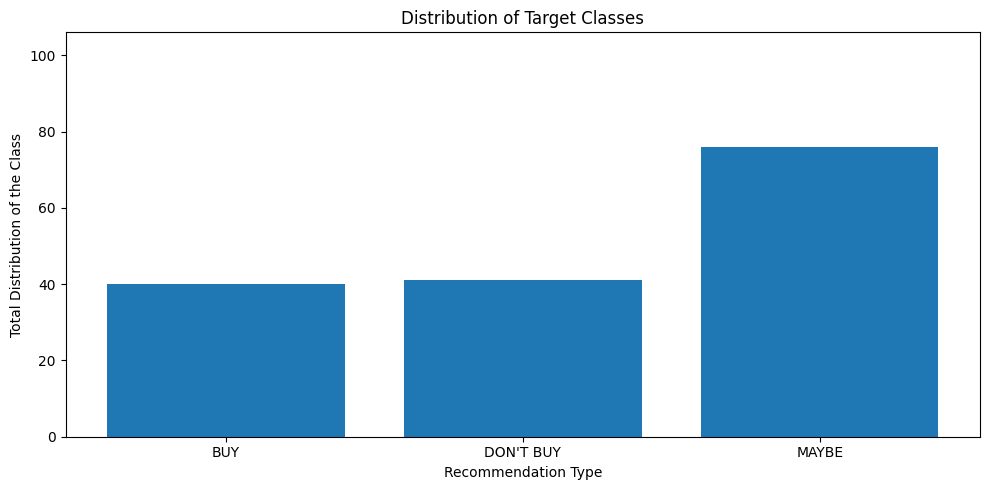

In [184]:
plt.figure(figsize=(10,5))
plt.bar(class_counts.index, class_counts.values)
plt.ylim(0, class_counts.max() + 30)
plt.xticks([0, 1, 2], ['BUY', 'DON\'T BUY', 'MAYBE'])

plt.title("Distribution of Target Classes")
plt.xlabel("Recommendation Type")
plt.ylabel("Total Distribution of the Class")

plt.tight_layout()
plt.show()

In [187]:
smote_tomek = SMOTETomek(random_state=42)
X_train_res, y_train_res = smote_tomek.fit_resample(scaled_train_df, encoded_y_train)

In [191]:
resampled_class_counts = pd.Series(y_train_res).value_counts()

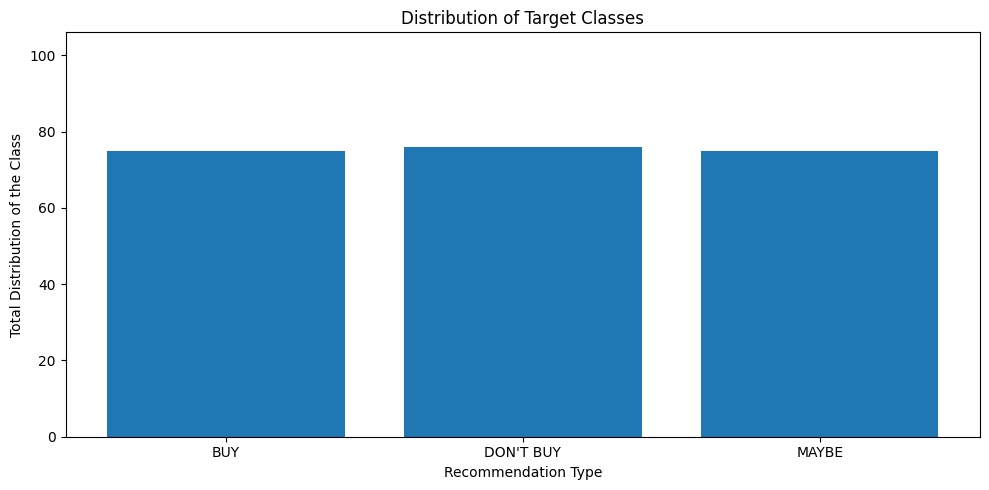

In [192]:
plt.figure(figsize=(10,5))
plt.bar(resampled_class_counts.index, resampled_class_counts.values)
plt.ylim(0, resampled_class_counts.max() + 30)
plt.xticks([0, 1, 2], ['BUY', 'DON\'T BUY', 'MAYBE'])

plt.title("Distribution of Target Classes")
plt.xlabel("Recommendation Type")
plt.ylabel("Total Distribution of the Class")

plt.tight_layout()
plt.show()

# Model Training

In [194]:
model = RandomForestClassifier(random_state=42)

In [200]:
params = {
    "criterion" : ['gini', 'entropy', 'log_loss'],
    "n_estimators" : [1, 3, 5, 7, 10],
    "max_depth" : [ 1, 3, 7, 10, None],
    "min_samples_split" : [3, 5, 7, 9, 10],
    "min_samples_leaf" : [ 1, 3, 5, 7, 9, 10],
    "max_features" : ['sqrt', 'log2', None],
    "class_weight" : ["balanced", "balanced_subsample"]
}

In [201]:
grid_search = GridSearchCV(model, params, cv=10, verbose=5, n_jobs=-1, return_train_score=True)

In [202]:
grid_search.fit(X_train_res, y_train_res)

Fitting 10 folds for each of 13500 candidates, totalling 135000 fits


GridSearchCV(cv=10, estimator=RandomForestClassifier(random_state=42),
             n_jobs=-1,
             param_grid={'class_weight': ['balanced', 'balanced_subsample'],
                         'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [1, 3, 7, 10, None],
                         'max_features': ['sqrt', 'log2', None],
                         'min_samples_leaf': [1, 3, 5, 7, 9, 10],
                         'min_samples_split': [3, 5, 7, 9, 10],
                         'n_estimators': [1, 3, 5, 7, 10]},
             return_train_score=True, verbose=5)

In [203]:
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

Best Parameters: {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 7}
Best Cross-Validation Score: 0.9519762845849803


In [231]:
model = RandomForestClassifier(class_weight='balanced', criterion= 'entropy', max_depth=10, max_features='sqrt', min_samples_leaf=1, min_samples_split=3, n_estimators=7, random_state=42)


In [232]:
model.fit(X_train_res, y_train_res)

RandomForestClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=10, min_samples_split=3, n_estimators=7,
                       random_state=42)

In [233]:
y_train_pred = model.predict(X_train_res)

In [234]:
train_accuracy = accuracy_score(y_train_res, y_train_pred)
print("Training Accuracy:", train_accuracy)

Training Accuracy: 0.995575221238938


In [235]:
print("Training Classification Report:")
print(classification_report(y_train_res, y_train_pred))

Training Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99        75
           1       1.00      1.00      1.00        76
           2       0.99      1.00      0.99        75

    accuracy                           1.00       226
   macro avg       1.00      1.00      1.00       226
weighted avg       1.00      1.00      1.00       226



In [236]:
print("Training Confusion Matrix:")
print(confusion_matrix(y_train_res, y_train_pred))

Training Confusion Matrix:
[[74  0  1]
 [ 0 76  0]
 [ 0  0 75]]


In [237]:
y_pred = model.predict(scaled_test_df)

In [238]:
test_accuracy = accuracy_score(encoded_y_test, y_pred)
print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.925


In [239]:
print("Test Classification Report:")
print(classification_report(encoded_y_test, y_pred))

Test Classification Report:
              precision    recall  f1-score   support

           0       0.83      1.00      0.91        10
           1       1.00      0.90      0.95        10
           2       0.95      0.90      0.92        20

    accuracy                           0.93        40
   macro avg       0.93      0.93      0.93        40
weighted avg       0.93      0.93      0.93        40



In [240]:
print("Test Confusion Matrix:")
print(confusion_matrix(encoded_y_test, y_pred))

Test Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 2  0 18]]
